# Analyze ternary LLM sparsity
Contributed by Anuj Pareek (apareek@student.ethz.ch) and Shien Zhu

### Mount Google Drive for model storage

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
!pwd
!ls
!ls drive/MyDrive/

/content
converted_model_bitnet-2b-4t.pth  packed_tcsc_bitnet-2b4t.pth  sample_data
converted_model_triLLM_1.1B.pth   packed_tcsc.pth
drive				  results


### Create a class to analyze the sparsity

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig


class AnalyzeSparsity:
    """A class to analyze sparsity of hugging face models"""

    def __init__(self, model_id=None):
        self.model_id = model_id
        self.sparsity_df = None  # dataframe to store sparsity results
        self.histogram_df = None  # dataframe to store
        self.weight_ranges_dict = None
        self.layer_type = None

        ## Create results folder (date-time based)
        self.date_time = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.base_dir = os.path.join(os.getcwd(), "results", self.date_time)
        os.makedirs(self.base_dir, exist_ok=True)

        ## For model-specific subfolders
        self.model_dir = None

        ## Store histogram_edges
        self._hist_edges = None  # used by histogram plotting

    ## Sanitize function removes unintended characters like "/"
    def _sanitize(self, s: str) -> str:
        return s.replace("/", "_")

    ## Make model directories as required
    def _ensure_model_dir(self):
        if self.model_id is None:
            return
        safe = self._sanitize(self.model_id)
        self.model_dir = os.path.join(self.base_dir, safe)
        os.makedirs(self.model_dir, exist_ok=True)


    def count_histogram(self, model_id, layer_type, discard_layer_names=[], bin_count=40):
        """
        Count a histogram of model weights in hugging face models.

        Inputs:
            model_id: str:  model id from Hugging Face
                            example: "SpectraSuite/TriLM_99M_Unpacked"

            layer_type: str: layer_type to count sparsity. example: "nn.Linear", "nn.Conv2d"

            discard_layer_names: list: strings of layer_names to discard, example ["lm_head"]

            bin_count: int: equal sized bins for histogram from min to max of weights.

        Returns:
            Updates and returns the self.histogram_df dataframe. Columns are [layer_name], the rows are counts in each bin
        """
        import numpy as np

        self.model_id = model_id
        self.layer_type = layer_type
        self._ensure_model_dir()

        # load model (same style as your code)
        model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="auto")
        model.eval()

        # map layer_type
        layer_cls = getattr(nn, layer_type.split(".")[-1]) if isinstance(layer_type, str) else layer_type

        # collect per-layer weights (CPU) and global min/max
        per_layer = {}
        gmin, gmax = None, None
        for name, module in model.named_modules():
            if not isinstance(module, layer_cls):
                continue

            lname = name if name else module.__class__.__name__

            # discard by substring match
            if discard_layer_names and any(sub in lname for sub in discard_layer_names if sub):
                continue

            w = module.weight.detach().float().cpu().view(-1).numpy()
            if w.size == 0:
                continue

            per_layer[lname] = w
            vmin, vmax = float(w.min()), float(w.max())
            gmin = vmin if gmin is None else min(gmin, vmin)
            gmax = vmax if gmax is None else max(gmax, vmax)

        if not per_layer:
            raise ValueError(f"No layers of type {layer_type} found in model {model_id}.")

        if gmin == gmax:
            gmin, gmax = gmin - 1e-6, gmax + 1e-6

        # shared edges; last bin will include the right edge during labeling
        edges = np.linspace(gmin, gmax, bin_count + 1)
        self._hist_edges = edges  # store for plotting

        # nice row labels
        row_labels = [f"[{edges[i]:.6g}, {edges[i+1]:.6g})" for i in range(bin_count - 1)]
        row_labels.append(f"[{edges[-2]:.6g}, {edges[-1]:.6g}]")  # last bin right-inclusive

        # counts per layer using numpy (same edges for all)
        data = {}
        for lname, w in per_layer.items():
            counts, _ = np.histogram(w, bins=edges)  # right-exclusive except last bin
            data[lname] = counts

        self.histogram_df = pd.DataFrame(data, index=row_labels)

        # Save CSV
        if self.model_dir is not None:
            safe = self._sanitize(self.model_id)
            self.histogram_df.to_csv(os.path.join(self.model_dir, f"histo_{safe}.csv"))

        return self.histogram_df



    def plot_histogram(self, title: str, normalized=True, show_mean_weight=True):
        """
        Plots histogram based on self.histogram_df dataframe. Builds it if it hasn't been built. x-axis is value of weight.

        Inputs:
            title: str: title for the plot. If none is given it defaults to "Histogram of weights for {model_id}"

            normalized: bool: whether to show counts or normalized values.

            show_mean_weight: bool: a dashed line indicating the mean value of weights across all layers

        Returns:
            saves the plot as histo_{model_id}.png file in a folder "{date_time}" in working dir.

        """

        if self.histogram_df is None:
            if self.model_id is None:
                raise ValueError("model_id is not set. Call count_histogram first.")
            # default: Linear layers, 20 bins
            self.count_histogram(self.model_id, "nn.Linear", bin_count=20)

        df = self.histogram_df
        edges = self._hist_edges if self._hist_edges is not None else None
        if edges is None:
            # fallback: infer edges uniformly across index range if missing
            bin_count = len(df.index)
            edges = np.linspace(0.0, 1.0, bin_count + 1)

        # Aggregate across layers
        agg = df.sum(axis=1).to_numpy(dtype=float)
        total = agg.sum()
        y = (agg / total) if (normalized and total > 0) else agg

        # Bar chart using left edges and bin widths
        lefts = edges[:-1]
        widths = np.diff(edges)

        fig, ax = plt.subplots(figsize=(9, 4))
        bars = ax.bar(lefts, y, width=widths, align="edge")

        ax.set_xlabel("Weight value")
        ax.set_ylabel("Density" if normalized else "Count")
        if not title:
            title = f"Histogram of {self.layer_type} Layer Weights for {self.model_id}"
        ax.set_title(title)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)

        # Mean line (dark grey), using bin centers approximation — legend only (no text on plot)
        legend_handles = [Patch(facecolor=bars.patches[0].get_facecolor(), label="Histogram")] if len(bars) else []
        if show_mean_weight and total > 0:
            centers = 0.5 * (edges[:-1] + edges[1:])
            mean_w = float((centers * agg).sum() / total)
            ax.axvline(mean_w, linestyle="--", linewidth=1, color='0.25')
            legend_handles.append(
                Line2D([0], [0], linestyle="--", color="0.25", label=f"Mean Weight {mean_w:.4g}")
            )

        if legend_handles:
            ax.legend(handles=legend_handles, loc="best", frameon=True)

        plt.tight_layout()

        # Save in model-specific folder
        safe = self._sanitize(self.model_id)
        out_dir = self.model_dir if self.model_dir is not None else self.base_dir
        filename = f"histo_{safe}_normalized{normalized}.png"
        out_path = os.path.join(out_dir, filename)
        plt.savefig(out_path, dpi=200, bbox_inches="tight", pad_inches=0.1)
        plt.close()



### Download Models and Analyze

In [ ]:
if __name__ == '__main__':

    ## Init class object
    an = AnalyzeSparsity()

    #### ==== MODEL 1.1B PARAMS ======== (REQUIRES LARGER RAM)
    model_id = "SpectraSuite/TriLM_1.1B_Unpacked"
    layer_type = "nn.Linear"
    discard_layer_names=["lm_head"] ## This layer is not ternary - weights are spread out across all bins.

    ## These weight bounds listed here are visible by inspection of the histo_SpectraSuite_TriLM_1.1B_Unpacked.csv
    weight_bounds={"+1": (0.006, 0.20), "0": (-0.006, 0.006), "-1": (-0.20, -0.006)}

    an.count_histogram(model_id, layer_type, discard_layer_names, bin_count=120)
    an.plot_histogram(title="TriLM 1.1B Weight Histogram", normalized=True, show_mean_weight=True)

    #### ==== MODEL 2B PARAMS ======== (REQUIRES LARGER RAM)
    model_id = "microsoft/bitnet-b1.58-2B-4T"
    layer_type = "nn.Linear"
    discard_layer_names=["lm_head"] ## This layer is not ternary - weights are spread out across all bins.

    ## These weight bounds listed here are visible by inspection of the histo .csv
    weight_bounds={"+1": (0.5, 1.5), "0": (-0.5, 0.5), "-1": (-1.5, -0.5)}

    print(f"{model_id}: High-RAM Environment required on Colab - otherwise errors with C^ ")

    an.count_sparsity(model_id, layer_type, discard_layer_names, weight_bounds)
    an.plot_sparsity(title="BitNet b1.58-2B-4T", normalized=True, show_mean_sparsity=True)

    an.count_histogram(model_id, layer_type, discard_layer_names, bin_count=40)
    an.plot_histogram(title="BitNet b1.58-2B-4T Weight Histogram", normalized=True, show_mean_weight=True)


In [ ]:
import numpy as np
#### ==== MODEL 1.1B PARAMS ======== (REQUIRES LARGER RAM)
model_id = "SpectraSuite/TriLM_1.1B_Unpacked"
layer_type = "nn.Linear"
discard_layer_names=["lm_head"] ## This layer is not ternary - weights are spread out across all bins.

## These weight bounds listed here are visible by inspection of the histo_SpectraSuite_TriLM_1.1B_Unpacked.csv
weight_bounds={"+1": (0.006, 0.20), "0": (-0.006, 0.006), "-1": (-0.20, -0.006)}
## Init class object
an = AnalyzeSparsity(model_id)
an._ensure_model_dir()

# load model (same style as your code)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="auto")
model.eval()


Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(50432, 1792)
    (layers): ModuleList(
      (0-23): 24 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=1792, out_features=1792, bias=False)
          (k_proj): Linear(in_features=1792, out_features=1792, bias=False)
          (v_proj): Linear(in_features=1792, out_features=1792, bias=False)
          (o_proj): Linear(in_features=1792, out_features=1792, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=1792, out_features=5120, bias=False)
          (up_proj): Linear(in_features=1792, out_features=5120, bias=False)
          (down_proj): Linear(in_features=5120, out_features=1792, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((1792,), eps=1e-05)
    (r

In [ ]:

# map layer_type
layer_cls = getattr(nn, layer_type.split(".")[-1]) if isinstance(layer_type, str) else layer_type


# collect per-layer weights (CPU) and global min/max
per_layer = {}
gmin, gmax = None, None
for name, module in model.named_modules():
    if not isinstance(module, layer_cls):
        continue

    lname = name if name else module.__class__.__name__

    # discard by substring match
    if discard_layer_names and any(sub in lname for sub in discard_layer_names if sub):
        continue

    w = module.weight.detach().float().cpu() #.view(-1).numpy()
    if w.size == 0:
        continue

    per_layer[lname] = w
    vmin, vmax = float(w.min()), float(w.max())
    gmin = vmin if gmin is None else min(gmin, vmin)
    gmax = vmax if gmax is None else max(gmax, vmax)

In [ ]:
# Analyze one layer
print(per_layer['model.layers.9.mlp.up_proj'].size())
proj = per_layer['model.layers.9.mlp.up_proj']
N = 5120
K = 1792
posth = 0.006
negth = -0.006
maxi = 0
mini = 5000
sum = 0

for n in range(N):
  # calculate +1 and -1
  vec = proj[n]
  pos = 0
  neg = 0
  for k in range(K):
    if vec[k] >= posth :
      pos+=1
    if vec[k] <= negth :
      neg+=1
  diff = pos - neg
  if(diff<mini):
    mini=diff
  if(diff>maxi):
    maxi=diff
print(maxi, mini)


torch.Size([5120, 1792])


KeyboardInterrupt: 

In [ ]:
# Analyze one layer
print(per_layer['model.layers.9.mlp.up_proj'].size())
proj = per_layer['model.layers.9.mlp.up_proj']
posth = 0.006
negth = -0.006
# 1. Use vectorized comparisons to create boolean masks
# 2. .sum(dim=1) counts True values across the K dimension (1792)
pos_counts = (proj >= posth).sum(dim=1)
neg_counts = (proj <= negth).sum(dim=1)

# 3. Calculate differences for all N rows at once
diffs = pos_counts - neg_counts
align = torch.minimum(pos_counts, neg_counts)
align_ratio = align * 2 / (pos_counts + neg_counts)
# 4. Use tensor methods to find max and min
# Use names like 'max_val' to avoid shadowing built-in functions
max_val = diffs.max().item()
min_val = diffs.min().item()

print(f"Max diff: {max_val}, Min diff: {min_val}")
print(f"Max align: {align.max().item()}, Min: {align.min().item()}, Avg: {torch.mean(align.float())}")
print(f"Max align_ratio: {align_ratio.max().item()}, Min: {align_ratio.min().item()}, Avg: {torch.mean(align_ratio.float())}")

torch.Size([5120, 1792])
Max diff: 119, Min diff: -111
Max align: 677, Min: 161, Avg: 530.6984252929688
Max align_ratio: 1.0, Min: 0.8721804618835449, Avg: 0.9760392904281616


# Convert a random tensor into TCSC format

In [ ]:
import torch
x = torch.rand([5120, 1792])
print(x)

tensor([[0.6391, 0.8357, 0.2738,  ..., 0.3967, 0.5919, 0.8552],
        [0.4891, 0.5956, 0.9345,  ..., 0.5610, 0.2681, 0.7550],
        [0.8333, 0.3664, 0.1345,  ..., 0.9387, 0.5646, 0.4866],
        ...,
        [0.5658, 0.3186, 0.6628,  ..., 0.3940, 0.5029, 0.0865],
        [0.4842, 0.8766, 0.7440,  ..., 0.1899, 0.6893, 0.5228],
        [0.1354, 0.3146, 0.5535,  ..., 0.3018, 0.2358, 0.1444]])


In [ ]:
def tensor2NaiveTCSC(x, posth, negth):
  pos = x > posth
  pos_counts = pos.sum(dim=1)
  col_index_pos, row_index_pos = torch.nonzero(pos, as_tuple=True)
  col_start_pos = torch.cat([x.new_zeros(1), torch.cumsum(pos_counts, dim=0)])
  neg = x < negth
  neg_counts = neg.sum(dim=1)
  col_index_neg, row_index_neg = torch.nonzero(neg, as_tuple=True)
  col_start_neg = torch.cat([x.new_zeros(1), torch.cumsum(neg_counts, dim=0)])
  return col_start_pos, row_index_pos, col_start_neg, row_index_neg

  # print(pos_indices)
  # print(pos_counts)
  # print(pos_start)

In [ ]:
x = torch.tensor([[1, 0, 1, 0],
                  [0, 1, 0, 1]])
col_start_pos, row_index_pos, col_start_neg, row_index_neg = tensor2NaiveTCSC(x, 0.5, -0.5)
print(col_start_pos, row_index_pos, col_start_neg, row_index_neg)
print(col_start_pos.dtype, row_index_pos.dtype, col_start_neg.dtype, row_index_neg.dtype)

tensor([0, 2, 4]) tensor([0, 2, 1, 3]) tensor([0, 0, 0]) tensor([], dtype=torch.int64)
torch.int64 torch.int64 torch.int64 torch.int64


In [ ]:
import torch
import torch.nn.functional as F

def tensor_2_Merged_Format(x, posth, negth):
    # 1. Mask and Count (Work per column for CSC-style)
    # Using dim=0 if 'x' is [Rows, Cols] and you want Column-Major
    pos_mask = x > posth
    neg_mask = x < negth

    pos_counts = pos_mask.sum(dim=0)
    neg_counts = neg_mask.sum(dim=0)
    total_counts_per_col = pos_counts + neg_counts

    # 2. Extract Indices (Column-Major order)
    # torch.nonzero returns [row, col]. We swap/sort to ensure it's Column-Major.
    pos_indices = torch.nonzero(pos_mask.T) # [col, row]
    neg_indices = torch.nonzero(neg_mask.T) # [col, row]

    pos_cols, pos_rows = pos_indices[:, 0], pos_indices[:, 1]
    neg_cols, neg_rows = neg_indices[:, 0], neg_indices[:, 1]

    # 3. Compute Metadata
    # Global pointer to where each column starts in the final 1D array
    col_ptr = F.pad(torch.cumsum(total_counts_per_col, 0)[:-1], (1, 0))

    align_counts = torch.min(pos_counts, neg_counts)
    remain_lengths = torch.abs(pos_counts - neg_counts)
    remain_values = torch.sign(pos_counts.float() - neg_counts.float()).to(torch.int32)

    # 4. Local Ranks (Position within the specific column)
    def get_ranks(counts, col_ptr_local):
        if counts.sum() == 0: return torch.empty(0, device=counts.device, dtype=torch.long)
        return torch.arange(counts.sum(), device=counts.device) - \
               torch.repeat_interleave(F.pad(torch.cumsum(counts, 0)[:-1], (1, 0)), counts)

    pos_ranks = get_ranks(pos_counts, None)
    neg_ranks = get_ranks(neg_counts, None)

    # 5. Interleaving Logic
    # We sort by: Column ID (primary) -> Interleave Logic (secondary)
    def get_sort_keys(cols, ranks, counts_self, counts_other, is_pos):
        col_align = torch.min(counts_self[cols], counts_other[cols])
        is_aligned = ranks < col_align

        # Interleave: Pairs take first 2*align slots, remainders take the rest
        pos_in_col = torch.where(
            is_aligned,
            ranks * 2 + (0 if is_pos else 1),
            col_align + ranks # Offsets remainders after the interleaved block
        )
        # 10^9 is usually safe for row/col counts in LLMs
        return cols.to(torch.int64) * 1_000_000 + pos_in_col

    pos_keys = get_sort_keys(pos_cols, pos_ranks, pos_counts, neg_counts, True)
    neg_keys = get_sort_keys(neg_cols, neg_ranks, neg_counts, pos_counts, False)

    # 6. Final Merge and Metadata Pack
    all_rows = torch.cat([pos_rows, neg_rows])
    all_keys = torch.cat([pos_keys, neg_keys])

    merged_indices = all_rows[torch.argsort(all_keys)]

    # Metadata: [Col_Ptr, Align_Count, Remain_Len, Remain_Val]
    metadata = torch.stack([
        col_ptr,
        align_counts,
        remain_lengths,
        remain_values
    ], dim=1)

    return merged_indices, metadata

  # Pseudo-code for a Matmul Kernel
def column_matmul(j, metadata, merged_indices, input_vector):
    ptr, align, r_len, r_val = metadata[j]
    res = 0

    # 1. Process Aligned Pairs (+1 and -1)
    # These are interleaved: [pos_idx, neg_idx, pos_idx, neg_idx...]
    for k in range(align):
        pos_idx = merged_indices[ptr + 2*k]
        neg_idx = merged_indices[ptr + 2*k + 1]
        res += (input_vector[pos_idx] - input_vector[neg_idx])

    # 2. Process Remainders
    # These are all the same value (r_val)
    remainder_start = ptr + 2*align
    for k in range(r_len):
        idx = merged_indices[remainder_start + k]
        res += r_val * input_vector[idx]

    return res

In [ ]:
x = torch.tensor([[1,   0, 1, -1],
                  [0,   1, 0,  1],
                  [-1, -1, 0,  1]])
indices, metadata = tensor_2_Merged_Format(x, 0.5, -0.5)
print(metadata)
print(indices)

tensor([[0, 1, 0, 0],
        [2, 1, 0, 0],
        [4, 0, 1, 1],
        [5, 1, 1, 1]])
tensor([0, 2, 1, 2, 0, 1, 0, 2])


# convert two models from torch tensor into Naive TCSC...

In [ ]:
## Loading model
import numpy as np
import time

# Start timer
start_time = time.perf_counter()
#### ==== MODEL 1.1B PARAMS ======== (REQUIRES LARGER RAM)
model_id = "SpectraSuite/TriLM_1.1B_Unpacked"
layer_type = "nn.Linear"
discard_layer_names=["lm_head"] ## This layer is not ternary - weights are spread out across all bins.

## These weight bounds listed here are visible by inspection of the histo_SpectraSuite_TriLM_1.1B_Unpacked.csv
weight_bounds={"+1": (0.006, 0.20), "0": (-0.006, 0.006), "-1": (-0.20, -0.006)}
## Init class object
an = AnalyzeSparsity(model_id)
an._ensure_model_dir()

# load model (same style as your code)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="auto")
model.eval()
# End timer
end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Loading Model took {execution_time:.4f} seconds to run.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading Model took 3.8470 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()
# map layer_type
layer_cls = getattr(nn, layer_type.split(".")[-1]) if isinstance(layer_type, str) else layer_type

state_dict = {}

for name, module in model.named_modules():
    if not isinstance(module, layer_cls):
        continue

    lname = name if name else module.__class__.__name__

    # discard by substring match
    if discard_layer_names and any(sub in lname for sub in discard_layer_names if sub):
        continue

    w = module.weight.detach().float().cpu() #.view(-1).numpy()
    if w.size == 0:
        continue
    col_start_pos, row_index_pos, col_start_neg, row_index_neg = tensor2NaiveTCSC(w, 0.006, -0.006)
    # packed_data = tensor2NaiveTCSC(x, 0.006, -0.006)
    module.weight = None
    state_dict[f"{lname}.col_start_pos"] = col_start_pos.to(torch.int32)
    state_dict[f"{lname}.row_index_pos"] = row_index_pos.to(torch.int16)
    state_dict[f"{lname}.col_start_neg"] = col_start_neg.to(torch.int32)
    state_dict[f"{lname}.row_index_neg"] = row_index_neg.to(torch.int16)
# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Converting Model took {execution_time:.4f} seconds to run.")

Converting Model took 40.1767 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()

# Save using PyTorch's native serialization (uses zip compression)
torch.save(state_dict, "./packed_tcsc_triLLM_1.1B.pth")

# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Saving converted tcsc took {execution_time:.4f} seconds to run.")

Saving converted tcsc took 4.0702 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()

# Save using PyTorch's native serialization (uses zip compression)
torch.save(model, "./converted_model_triLLM_1.1B.pth")

# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Saving converted tcsc took {execution_time:.4f} seconds to run.")

Saving converted tcsc took 6.3871 seconds to run.


In [ ]:
## Loading model
import numpy as np
import time

# Start timer
start_time = time.perf_counter()
#### ==== MODEL 2B PARAMS ======== (REQUIRES LARGER RAM)
model_id = "microsoft/bitnet-b1.58-2B-4T"
layer_type = "nn.Linear"
discard_layer_names=["lm_head"] ## This layer is not ternary - weights are spread out across all bins.

## These weight bounds listed here are visible by inspection of the histo .csv
weight_bounds={"+1": (0.5, 1.5), "0": (-0.5, 0.5), "-1": (-1.5, -0.5)}
## Init class object
an = AnalyzeSparsity(model_id)
an._ensure_model_dir()

# load model (same style as your code)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="auto")
model.eval()
# End timer
end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Loading Model took {execution_time:.4f} seconds to run.")


You don't have a GPU available to load the model, the inference will be slow because of weight unpacking


Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

Loading Model took 16.2860 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()
# map layer_type
layer_cls = getattr(nn, layer_type.split(".")[-1]) if isinstance(layer_type, str) else layer_type

state_dict = {}

for name, module in model.named_modules():
    if not isinstance(module, layer_cls):
        continue

    lname = name if name else module.__class__.__name__

    # discard by substring match
    if discard_layer_names and any(sub in lname for sub in discard_layer_names if sub):
        continue

    w = module.weight.detach().float().cpu() #.view(-1).numpy()
    if w.size == 0:
        continue
    col_start_pos, row_index_pos, col_start_neg, row_index_neg = tensor2NaiveTCSC(w, 0.5, -0.5)
    # packed_data = tensor2NaiveTCSC(x, 0.006, -0.006)
    module.weight = None
    state_dict[f"{lname}.col_start_pos"] = col_start_pos.to(torch.int32)
    state_dict[f"{lname}.row_index_pos"] = row_index_pos.to(torch.int16)
    state_dict[f"{lname}.col_start_neg"] = col_start_neg.to(torch.int32)
    state_dict[f"{lname}.row_index_neg"] = row_index_neg.to(torch.int16)
# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Converting Model took {execution_time:.4f} seconds to run.")

Converting Model took 14.7718 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()

# Save using PyTorch's native serialization (uses zip compression)
torch.save(state_dict, "./packed_tcsc_bitnet-2b4t.pth")

# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Saving converted tcsc took {execution_time:.4f} seconds to run.")

Saving converted tcsc took 4.0232 seconds to run.


In [ ]:
# Start timer
start_time = time.perf_counter()

# Save using PyTorch's native serialization (uses zip compression)
torch.save(model, "./converted_model_bitnet-2b-4t.pth")

# End timer
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Saving converted tcsc took {execution_time:.4f} seconds to run.")

Saving converted tcsc took 10.0860 seconds to run.


# Draw a graph

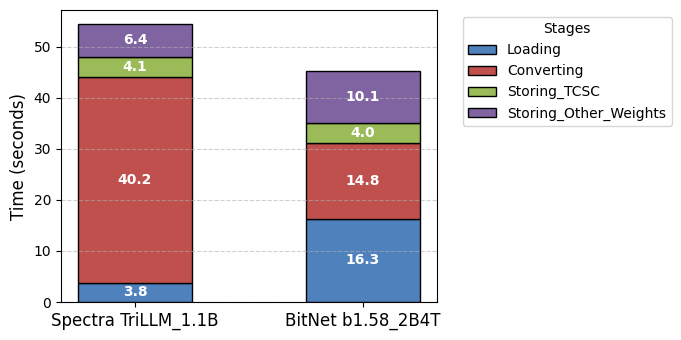

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data
apps = ['Spectra TriLLM_1.1B', 'BitNet b1.58_2B4T']
categories = ['Loading', 'Converting', 'Storing_TCSC', 'Storing_Other_Weights']

# Values for each category across the apps
data = {
    'Loading': [3.8, 16.3],
    'Converting': [40.2, 14.8],
    'Storing_TCSC': [4.1, 4.0],
    'Storing_Other_Weights': [6.4, 10.1]
}

# 2. Setup positions and colors
x = np.arange(len(apps))
width = 0.5
colors = ['#4f81bd', '#c0504d', '#9bbb59', '#8064a2']
bottom = np.zeros(len(apps))

fig, ax = plt.subplots(figsize=(7, 3.5))

# 3. Build the stacked bars
for i, category in enumerate(categories):
    vals = np.array(data[category])
    bars = ax.bar(x, vals, width, bottom=bottom, label=category,
                  color=colors[i], edgecolor='black')

    # Optional: Add text labels inside the bars for values > 2s
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bottom[j] + height/2,
                    f'{height:.1f}', ha='center', va='center',
                    color='white', fontweight='bold')

    bottom += vals  # Update the base for the next stack

# 4. Formatting
ax.set_ylabel('Time (seconds)', fontsize=12)
#ax.set_title('Runtime Breakdown: triLLM vs BitNet', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(apps, fontsize=12)
ax.legend(title='Stages', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Export (using the 'tight' setting for complete PDFs)
plt.tight_layout()
plt.savefig('runtime_breakdown.pdf', bbox_inches='tight')
plt.show()